## Packages installed 
# 1. Python install through  https://www.python.org/downloads/ , then check version through terminal - pip python --version    
# 2. Pip Python package manager comes with Python installation, check version through terminal - pip --version , update pip through terminal - python -m pip install --upgrade pip
# 3. Setup interpreter Ctrl+Shift P - Python: Select Interpreter - select the one with Python 3.11.4
# 4. Jupyter notebook is environment for Python , through terminal- pip install notebook   
# 5. Pandas provides data structures and data analysis tools for Python, through terminal - pip install pandas
# 6. Numpy provides support for large, multi-dimensional arrays and matrices, data computation tools, install terminal - pip install numpy
# 7. tzdata provides time zone data for Python, through terminal - pip install tzdata


## To transfer data from Python to a PostgreSQL database, you can use the following steps:
# 1. Install the required package for PostgreSQL connection (e.g., psycopg2 and sqlalchemy) through terminal - !pip install sqlalchemy  and !pip install psycopg2-binary
# 2. Import the necessary libraries for database connection and data transfer (e.g., psycopg2, sqlalchemy).

In [36]:
import json
import mysql.connector as connector  # import mysql.connector library for connect to mysql database and perform sql query

import pandas as pd  # import pandas library for data manipulation and analysis
import sqlite3  # import sqlite3 library for connect to sqlite database and perform sql query


In [37]:

# process_using_MySql_Connector function is responsible for connecting to the MySQL database using the mysql.connector library and transferring data from a DataFrame to the MySQL database. It first calls the DB_Config function to retrieve the MySQL connection settings from the settings.json file. If the connection settings are found, it establishes a connection to the MySQL database using the mysql.connector library and the retrieved connection settings. It then checks if the connection is successful and if so, it calls the process_mysql_cmd function to execute a series of MySQL commands to create a table, insert records, and select records from the 'customers' table in the MySQL database. If any exceptions occur during the connection process, it catches the exception and prints an error message. Finally, it ensures that the MySQL connection is closed properly after all operations are completed.
def process_using_MySql_Connector():   
    
   dbconfig=None;
   conn=None; 

   try:
          dbconfig=DB_Config("MySQL") # call the DB_Config function with the argument "MySQL" to retrieve the MySQL connection settings from the settings.json file and store them in the variable dbconfig.;
        
          if not dbconfig is None:
               print(f"Connecting to MySQL database using MySQL Connector with the following settings: Server:- {dbconfig['server']} ' Port:- ' {dbconfig.get('port', 3306)} ' Database:- ' {dbconfig['database']} ' Username:- ' {dbconfig['username']} ' Password:- ' {dbconfig['password']}") # print the MySQL connection settings to verify that the correct connection details have been retrieved from the settings.json file.

               conn = connector.connect(
                                        host=dbconfig['server'],
                                        port=dbconfig.get('port', 3306),
                                        database=dbconfig['database'],
                                        user=dbconfig['username'],
                                        password=dbconfig['password']
                                       ) # establish a connection to the MySQL database using the mysql.connector library and the connection settings retrieved from the settings.json file.
             
               print(conn) # print the connection object to verify that the connection to the MySQL database has been established successfully.

               if conn.is_connected():
                    print("Connected to MySQL database using MySQL Connector.") # You can add code here to transfer data from the DataFrame to the MySQL database using the connection object.

                    process_mysql_cmd(conn);

               else:
                  print(f"No MySQL connection settings found. Please check your settings.json.")

          else:
               print(f"No MySQL connection settings found. Please check your settings.json.")
             
        
   except Exception as e:
        print(f"Error connecting to MySQL database: {e}")

   finally:
        if 'connection' in locals() and conn.is_connected():
            conn.close()
            print("MySQL connection closed.")


# DB_Config function is responsible for reading the connection details from the settings.json file and returning the database configuration for the specified database type (PostgreSQL or MySQL). It checks if the provided database type is recognized, reads the settings.json file, retrieves the list of connections, and finds the connection settings for the specified database type. If successful, it returns the database configuration; otherwise, it prints appropriate error messages and returns None.
def DB_Config(dbtype):

    print("Reading settings.json file for connection details...")

    # 1. Simple assignment (most common)
    read_file = None
    settings_path = '.vscode/settings.json'
    dbconfig = None      

    # 2. Multiple assignment
    host, port, dbname, user, password = None, None, None, None, None

    # 3. Default values    
    settings = {}
    connections = None

    try:
         if not dbtype.lower() in ['mysql']:
            print(f"Database type '{dbtype}' is not recognized. No data transfer will be performed.") # print a message indicating that the provided database type is not recognized and that no data transfer will be performed.           
            return dbconfig   

         if settings_path != '' and not settings_path is None: 
            read_file = open(settings_path, 'r') # open the settings.json file in read mode to access the connection settings.
         else:    
            print(f"No settings file found. Please check your settings.json.")
            return dbconfig

         if not read_file is None:            
            settings = json.load(read_file) # load the contents of the settings.json file into a Python dictionary to access the connection settings.
         else:    
            print(f"No connections found. Please check your settings.json.")
            return dbconfig

         if not settings is None:
            connections = settings.get('sqltools.connections',None) # retrieve the list of database connections from the settings dictionary using the key 'sqltools.connections' to access the connection settings.
         else:    
            print(f"No connections found. Please check your settings.json.")
            return dbconfig

         if not connections is None:    

            if dbtype.lower() =='mysql':
               dbconfig = next((c for c in connections 
                       if c['driver'] == 'MySQL' and c['database'] == 'customer_behavior'), None) # use a list comprehension to find the first MySQL connection in the list of connections that has a driver of 'MySQL' and a database name of 'customer_behavior'.
               
               print(f"Found MySQL connection settings. Server:- {dbconfig['server']} ' Port:- ' {dbconfig.get('port', 3306)} ' Database:- ' {dbconfig['database']} ' Username:- ' {dbconfig['username']} ' Password:- ' {dbconfig['password']}") # print the server and database name from the MySQL connection settings to verify that the correct connection details have been retrieved from the settings.json file.       
               
            return dbconfig      
            
         else:    
            print(f"No connections found. Please check your settings.json.")
            return dbconfig

    except Exception as e:
        print(f"Connection failed: {e}")
        return dbconfig
    finally:
        if not read_file is None:
            read_file.close()
            

# The process_mysql_cmd function is responsible for executing a series of MySQL commands to create a table, insert records, and select records from the 'customers' table in the MySQL database. It first calls the cmd_create_table function to create the 'customers' table if it does not already exist. Then, it checks if any records were inserted (based on the rec_count variable) and if so, it calls the cmd_select_records function to select and print all records from the 'customers' table to verify that the record has been inserted successfully. If any exceptions occur during the execution of the MySQL commands, it catches the exception and prints an error message.
def process_mysql_cmd(conn):

    rec_count = 0;
    conditional_clause=True;
    order_clause=True;

    try:
        
        # Example SQL command to create a table
        cmd_create_table(conn);
    
        rec_count = cmd_insert_into_table(conn) # call the cmd_insert_into_table function to insert a record into the 'customers' table in the MySQL database.

        if rec_count > 0:
            cmd_select_records(conn,conditional_clause,order_clause) # call the cmd_select_records function to select and print all records from the 'customers' table in the MySQL database to verify that the record has been inserted successfully.
        
    except Exception as e:
        print(f"Error executing MySQL command: {e}")

# The cmd_create_table function is responsible for creating a table named 'customers' in the MySQL database if it does not already exist. It uses a cursor object to execute an SQL command that defines the structure of the 'customers' table, which includes columns for id, name, and address. After executing the command to create the table, it prints a message indicating that the table has been created successfully. Then, it executes another SQL command to show the tables in the database and prints the names of the tables to verify that the 'customers' table has been created successfully. If any exceptions occur during the execution of the SQL commands, it catches the exception and prints an error message.
def cmd_create_table(conn):

    mycursor = conn.cursor() # create a cursor object from the MySQL connection to execute SQL commands.

    try:

        create_table_query = """
        CREATE TABLE IF NOT EXISTS customers (
            id INT AUTO_INCREMENT PRIMARY KEY,
            name VARCHAR(255) NOT NULL,
            address VARCHAR(255)            
        )
        """
        # define an SQL command to create a table named 'customers' with columns for id, name, email, and created_at.

        mycursor.execute(create_table_query) # execute the SQL command to create the table in the MySQL database.

        print("Table 'customers' created successfully.") # print a message indicating that the table has been created successfully.

        mycursor.execute("SHOW TABLES") # execute an SQL command to show the tables in the MySQL database to verify that the 'customers' table has been created successfully.

        if not mycursor is None:
            print("Tables in the database:")

            print("Print Table Name using for loop:")
            for tb in mycursor: 
                print(tb)

           
        
    except Exception as e:
        print(f"Error executing MySQL command: {e}")

# The cmd_insert_into_table function is responsible for inserting multiple records into the 'customers' table in the MySQL database. It defines an SQL command to insert records into the 'customers' table with the name and address columns. It then defines a list of values to be inserted as multiple records into the 'customers' table. It prints the name and address values that will be inserted to verify that the correct data is being inserted. It uses the executemany() method of the cursor object to execute the SQL command and insert all the records in a single operation for improved performance. After executing the command, it commits the transaction to save the changes to the MySQL database. It then retrieves the number of records inserted using the rowcount attribute of the cursor object and prints a message indicating how many records were inserted successfully. If any exceptions occur during the execution of the SQL commands, it catches the exception and prints an error message.
def cmd_insert_into_table(conn):
    
    rec_count = 0;
    mycursor = conn.cursor();

    try:
        
        truncate_table_query = "TRUNCATE TABLE customers;" # define an SQL command to truncate the 'customers' table to remove all existing records before inserting new records.

        truncate_table_query+= "ALTER TABLE customers AUTO_INCREMENT = 1;" # define an SQL command to reset the auto-increment value of the 'customers' table to 1 after truncating the table.

        mycursor.execute(truncate_table_query) # execute the SQL command to truncate the 'customers' table and reset the auto-increment value in the MySQL database.

        insert_record_query = "INSERT INTO customers (name, address) VALUES (%s, %s)" # define an SQL command to insert a record into the 'customers' table with the name and address columns.

        # define an SQL command to insert a record into the 'customers' table with the name
        insert_record_values = [
                                ("John Doe", "123 Main St"),
                                ("Jane Smith", "456 Elm St"),
                                ("Alice Johnson", "789 Oak St"),
                                ("Bob Brown", "321 Pine St"),
                                ("Charlie Davis", "654 Maple St"),
                                ("Eve Wilson", "987 Cedar St"),
                                ("Frank Garcia", "246 Birch St"),
                                ("Grace Martinez", "159 Walnut St"),
                                ("Hank Rodriguez", "753 Oak St"),
                                ("Ivy Hernandez", "147 Maple St"),
                                ("Jack Lee", "369 Pine St"),
                                ("Kate Kim", "852 Birch St"),
                                ("Lily Park", "159 Cedar St"),
                                ("Mike Kim", "753 Oak St"),
                                ("Nancy Kim", "147 Maple St"),
                                ("Oscar Kim", "369 Pine St"),
                                ("Penny Kim", "852 Birch St"),
                                ("Quinn Kim", "159 Cedar St"),
                                ("Ralph Kim", "753 Oak St"),
                                ("Sally Kim", "147 Maple St"),
                                ("Tina Kim", "369 Pine St")
                               ] # define the values to be inserted multiple records into the 'customers' table for the name and address columns.

        print(f"Inserting record into 'customers' table: Name:- {insert_record_values[0]} ' Address:- ' {insert_record_values[1]}") # print the name and address values that will be inserted into the 'customers' table to verify that the correct data is being inserted. 
        
        #mycursor.execute(insert_record_query, insert_record_values) # execute the SQL command to insert SINGLE record into the 'customers' table.

        mycursor.executemany(insert_record_query, insert_record_values) # execute the SQL command to insert multiple records into the 'customers' table using the executemany() method to insert all the records in a single operation for improved performance.

        conn.commit() # commit the transaction to save the changes to the MySQL database.                

        rec_count = mycursor.rowcount # get the number of records inserted using the rowcount attribute of the cursor object to verify that the correct number of records has been inserted into the 'customers' table.

        if rec_count > 0:
            print(f"{rec_count} Record inserted successfully.") # print a message indicating that the record has been inserted successfully.                  
        else:
            print("No records inserted.")
              
        return rec_count;

    except Exception as e:
        print(f"Error executing MySQL command: {e}")

        return rec_count;


# The cmd_select_records function is responsible for selecting and printing records from the 'customers' table in the MySQL database based on optional conditional and order clauses. It takes a MySQL connection object, a boolean flag for the conditional clause, and a boolean flag for the order clause as parameters. It defines the conditional and order clauses based on the provided flags and constructs an SQL command to select records from the 'customers' table accordingly. It then executes the SQL command, fetches all the records returned by the command, and prints each record. If any exceptions occur during the execution of the SQL commands, it catches the exception and prints an error message.
def cmd_select_records(conn, conditional_clause=False,order_clause=False):
 
    mycursor = conn.cursor();
    conditional_str=None;
    order_str=None;

    try:
        if conditional_clause:

            # mycursor.execute("SELECT name, address FROM customers WHERE id = %s", (10,))

            # conditional_str = "WHERE id = 10"    


            # conditional_str = "WHERE name = 'Oscar Kim'" # define a conditional clause to filter the records based on the name column being equal to 'Oscar Kim' to be used in the SQL command to select records from the 'customers' table.

            # mycursor.execute("SELECT name, address FROM customers WHERE name = %s", ('Oscar Kim',)) # execute an SQL command to select records from the 'customers' table with a conditional clause to filter the results based on the name column.


            conditional_str = "WHERE name like '%Kim%'" # define a conditional clause to filter the records based on the name column containing 'Kim' to be used in the SQL command to select records from the 'customers' table.

            # mycursor.execute("SELECT name, address FROM customers WHERE name like %s", ('%Kim%',)) # execute an SQL command to select records from the 'customers' table with a conditional clause to filter the results based on the name column.

        if order_clause:

            order_str = "ORDER BY name DESC" # define an order clause to sort the records based on the name column to be used in the SQL command to select records from the 'customers' table.


            # mycursor.execute("SELECT name, address FROM customers ORDER BY %s", ('name',)) # execute an SQL command to select records from the 'customers' table with an order clause to sort the results based on the name column.
            
        
        mycursor.execute(f"SELECT name, address FROM customers {conditional_str} {order_str}") # execute an SQL command to select all records from the 'customers' table to verify that the record has been inserted successfully. 

        myresult = mycursor.fetchall() # fetch all the records returned by the SQL command to access the data that has been inserted into the 'customers' table.

        for rec in myresult:
            print(rec)

    except Exception as e:
        print(f"Error executing MySQL command: {e}")


In [38]:
# The process_using_SQLite function is responsible for connecting to a SQLite database using the sqlite3 library and executing a series of SQLite commands to create a table, insert records, and select records from the 'customers' table in the SQLite database. It creates a connection to an in-memory SQLite database, prints a message indicating that the connection has been established successfully, and then calls the process_sqlite_cmd function to execute the SQLite commands. If any exceptions occur during the connection process, it catches the exception and prints an error message.
def process_using_SQLite():
    try:
        # Create a connection to SQLite database
        conn = sqlite3.connect(':memory:') # use an in-memory database for testing purposes. You can replace ':memory:' with a file path to create a persistent SQLite database.

        print(f"Connected to SQLite database using SQLite Connector:-{conn}.")     

        process_sqlite_cmd(conn);

    except Exception as e:
        print(f"Error connecting to SQLite database: {e}")


def process_sqlite_cmd(conn):
    rec_count = 0;

    try:
        sqlite_cmd_create_table(conn) # call the sqlite_cmd_create_table function to create the 'customers' table in the SQLite database.

        rec_count = sqlite_cmd_insert_into_table(conn) # call the sqlite_cmd_insert_into_table function to insert a record into the 'customers' table in the SQLite database.

        if rec_count > 0:
            sqlite_cmd_select_records(conn) # call the sqlite_cmd_select_records function to select and print all records from the 'customers' table in the SQLite database to verify that the record has been inserted successfully.

    except Exception as e:
        print(f"Error executing SQLite command: {e}")

        
def sqlite_cmd_create_table(conn):
    try:

        # drop_table_query = "DROP TABLE IF EXISTS customers;" # define an SQL command to drop the 'customers' table if it already exists to ensure that the table is created fresh for testing purposes.

        # conn.execute(drop_table_query); # execute the SQL command to drop the 'customers' table if it already exists in the SQLite database to ensure that the table is created fresh for testing purposes.
        # conn.commit() # commit the transaction to save the changes to the SQLite database.

        create_table_query = """    
                                CREATE TABLE customers (
                                    customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
                                    name TEXT NOT NULL,
                                    country TEXT NOT NULL,
                                    signup_date TEXT NOT NULL
                                );

                                CREATE TABLE orders (
                                    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
                                    customer_id INTEGER NOT NULL,            
                                    order_date TEXT NOT NULL,
                                    product_category TEXT NOT NULL,
                                    order_amount REAL NOT NULL,
                                    payment_method TEXT NOT NULL,
                                    FOREIGN KEY (customer_id) REFERENCES customers (customer_id)
                                );
                            """ # define an SQL command to create a table named 'customers' with columns for id, name, and address.

       
        process_sqlite_query(conn, create_table_query, None, 'CREATE', True) # execute the SQL command to create the table in the SQLite database using a helper function to handle the execution of the SQL command.

        print("Table 'customers' and 'orders' created successfully in SQLite database.") # print a message indicating that the table has been created successfully.

    except Exception as e:
        print(f"Error executing SQLite command: {e}")



def sqlite_cmd_insert_into_table(conn):
    
    rec_count = 0;

    try:

        
        # truncate_table_query = "TRUNCATE TABLE customers;" # define an SQL command to truncate the 'customers' table to remove all existing records before inserting new records.

        # truncate_table_query+= "ALTER TABLE customers AUTO_INCREMENT = 1;" # define an SQL command to reset the auto-increment value of the 'customers' table to 1 after truncating the table.

        # conn.execute(truncate_table_query) # execute the SQL command to truncate the 'customers' table and reset the auto-increment value in the SQLite database.

        # Example SQL command to insert a record into the 'customers' table
        insert_record_query = """                               

                                INSERT INTO customers (name, country, signup_date) 
                                VALUES ('Aisha','India', '2024-01-10'),
                                       ('Rahul', 'India', '2024-02-05'),
                                       ('Sophia', 'USA', '2024-01-20'),
                                       ('Liam', 'UK', '2024-03-01'),
                                       ('Mei', 'Singapore', '2024-02-15');                                

                                INSERT INTO orders (customer_id, order_date, product_category, order_amount, payment_method)
                                VALUES (1, '2024-03-01', 'Books', 1200.00, 'CARD'),
                                       (1, '2024-03-10', 'Electronics', 8500.00, 'UPI'),
                                       (2, '2024-03-05', 'Groceries', 1500.00, 'COD'),
                                       (2, '2024-03-18', 'Books', 700.00, 'CARD'),
                                       (3, '2024-03-12', 'Electronics', 9000.00, 'CARD'),
                                       (3, '2024-03-25', 'Fashion', 3000.00, 'CARD'),
                                       (4, '2024-03-07', 'Books', 900.00, 'UPI'),
                                       (4, '2024-03-21', 'Groceries', 2200.00, 'CARD'),
                                       (5, '2024-03-15', 'Electronics', 7500.00, 'UPI'),
                                       (5, '2024-03-28', 'Books', 1100.00, 'CARD');
                                       
                              """ # define an SQL command to insert a record into the 'customers' table with the name and address columns.
        
        process_sqlite_query(conn, insert_record_query, None, 'INSERT', True) # execute the SQL command to create the table in the SQLite database using a helper function to handle the execution of the SQL command.
        rec_count = conn.total_changes # get the number of records inserted using the total_changes attribute of the connection object to verify that the correct number of records has been inserted into the 'customers' table.

        if rec_count > 0:
            print(f"{rec_count} Record inserted successfully.") # print a message indicating that the record has been inserted successfully.                  
        else:
            print("No records inserted.")
              
        return rec_count;

    except Exception as e:
        print(f"Error executing SQLite command: {e}")

        return rec_count;

def sqlite_cmd_select_records(conn):
    
    try:
        select_query = "SELECT * FROM customers" # define an SQL command to select all records from the 'customers' table to verify that the record has been inserted successfully. 

        df_customers=process_sqlite_query(conn,select_query,None,'SELECT',False) # read the records from the 'customers' table into a DataFrame using the read_sql_query function from pandas to verify that the record has been inserted successfully.

        display(df_customers) # execute the SQL command to select records from the 'customers' table in the SQLite database.

        
        
        select_query = "SELECT * FROM orders" # define an SQL command to select all records from the 'orders' table to verify that the record has been inserted successfully. 

        df_orders=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.
        
        display(df_orders)


        select_query="""
                     SELECT o.order_id, c.name, c.country, o.order_date, o.product_category, o.order_amount, o.payment_method
                     FROM orders o
                     INNER JOIN customers c ON o.customer_id = c.customer_id
                     WHERE c.country = 'India'  
                     """

        df_ordersinindia=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        display(df_ordersinindia)

        select_query="""
                     SELECT o.order_id, c.name, c.country, o.order_date, o.product_category, o.order_amount, o.payment_method
                     FROM orders o
                     INNER JOIN customers c ON o.customer_id = c.customer_id
                     WHERE o.order_amount > 5000  
                     order by o.order_amount desc
                     """

        df_ordersbasedonamount=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        display(df_ordersbasedonamount)

        select_query="""
                     SELECT o.order_id, c.name, c.country, o.order_date, o.product_category, o.order_amount,  
                     o.order_amount*0.10 discounted_amount, o.payment_method
                     FROM orders o
                     INNER JOIN customers c ON o.customer_id = c.customer_id
                     """

        df_orderswithdiscount=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        display(df_orderswithdiscount)

        select_query="""
                     SELECT o.product_category,o.order_amount*0.10 discounted_amount,count(o.order_id) total_orders,
                     sum(o.order_amount) total_amount,avg(o.order_amount) average_amount
                     FROM orders o
                     INNER JOIN customers c ON o.customer_id = c.customer_id    
                     WHERE c.country = 'India'                 
                     group by o.product_category   
                     HAVING sum(o.order_amount) > 1500                  
                     ORDER BY total_amount DESC
                     """

        df_ordersproductwiseinindia=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        display(df_ordersproductwiseinindia)

        select_query="""
                     SELECT o.product_category,o.order_amount*0.10 discounted_amount,count(o.order_id) total_orders,
                     sum(o.order_amount) total_amount,avg(o.order_amount) average_amount
                     FROM orders o
                     INNER JOIN customers c ON o.customer_id = c.customer_id                             
                     group by o.product_category                        
                     ORDER BY total_amount DESC
                     """

        df_orderscategorywise=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        display(df_orderscategorywise)


        plot_charts(df_orderscategorywise,"Orders_Categorywise")


        select_query="""
                     SELECT c.customer_id,c.name,c.country,
                     count(o.order_id) total_orders, 
                     sum(o.order_amount) total_amount
                     FROM customers c
                     INNER JOIN orders o ON o.customer_id = c.customer_id                             
                     group by c.customer_id,c.name,c.country
                     ORDER BY total_amount DESC
                     """

        df_orderscustomerwise=process_sqlite_query(conn, select_query,None,'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        df_orderscustomerwise=df_orderscustomerwise.query('total_amount > 8000') # filter the DataFrame to include only customers with a total amount greater than 8000 to focus on high-value customers for further analysis. 

        display(df_orderscustomerwise)

        paramterized_fn(conn,'India');        
        paramterized_fn(conn,'USA');
        paramterized_fn(conn,'UK');
        paramterized_fn(conn,'Singapore');


    except Exception as e:
        print(f"Error executing SQLite command: {e}")



def plot_charts(df,datatype):
    try:
        import matplotlib.pyplot as plt;      

        if df.empty:
            print("No data available to plot.")
            return
        
        if datatype == "Orders_Categorywise":

            # Bar plot for total amount by product category         
            df.plot(kind='bar', 
                    x='product_category', 
                    y='total_amount',
                    figsize=(10, 6),    
                    legend=False,
                    rot=0               
                    ) # create a bar plot using the plot function from pandas to visualize the total amount by product category from the DataFrame.
                    
            plt.title('Total Amount by Product Category')
            plt.xlabel('Product Category')
            plt.ylabel('Total Amount')        
            plt.tight_layout()
            plt.show()



            # Pie chart for total orders by product category       
            df.plot(kind='pie',                
                    y='total_orders',
                    labels=df['product_category'],
                    figsize=(10, 6),
                    legend=True,
                    autopct='%1.1f%%',
                    startangle=140
                ) # create a pie chart using the plot function from pandas to visualize the total orders by product category from the DataFrame.

            plt.title('Total Orders by Product Category')
            plt.axis('equal')
            plt.show() 

    except Exception as e:
        print(f"Error plotting charts: {e}")


def paramterized_fn(conn,country):
    try:
        select_query="""
                     SELECT o.order_id, c.name, c.country, o.order_date, o.product_category, o.order_amount, o.payment_method
                     FROM orders o
                     INNER JOIN customers c ON o.customer_id = c.customer_id
                     WHERE c.country = :country  
                     order by o.order_amount desc
                     """

        df_ordersbasedoncountry=process_sqlite_query(conn, select_query,{'country': country},'SELECT',False) # execute the SQL command to select records from the 'orders' table in the SQLite database.

        display(df_ordersbasedoncountry)

        print(f"Number of records for Order in {country}: {df_ordersbasedoncountry.shape[0]}") # get the number of records in the DataFrame to verify that the correct number of records has been retrieved from the SQLite database.

    except Exception as e:
        print(f"Error executing parameterized query: {e}")


def process_sqlite_query(conn,query=None, params=None,ACTION='SELECT',MultiStatement=False):
    try:
        if conn is not None:
            if query is not None:
                if params is None:
                    params={};                    
                
                if ACTION in ['CREATE','INSERT']:
                    if MultiStatement:
                        conn.executescript(query) # execute the provided SQL command with parameters using the SQLite connection.
                    else:
                        conn.execute(query, params) # execute the provided SQL command with parameters using the SQLite connection.

                    conn.commit() # commit the transaction to save the changes to the SQLite database.
                elif ACTION == 'SELECT': 
                    return pd.read_sql_query(sql=query, con=conn,params=params) # execute the provided SQL command with parameters using the SQLite connection. --- IGNORE ---               

    except Exception as e:
        print(f"Error executing SQLite queries: {e}")

Database type selected for connection: SQLite
Connected to SQLite database using SQLite Connector:-<sqlite3.Connection object at 0x0000020AC6928F40>.
Table 'customers' and 'orders' created successfully in SQLite database.
15 Record inserted successfully.


,customer_id,name,country,signup_date
0,1,Aisha,India,2024-01-10
1,2,Rahul,India,2024-02-05
2,3,Sophia,USA,2024-01-20
3,4,Liam,UK,2024-03-01
4,5,Mei,Singapore,2024-02-15


,order_id,customer_id,order_date,product_category,order_amount,payment_method
0,1,1,2024-03-01,Books,1200.0,CARD
1,2,1,2024-03-10,Electronics,8500.0,UPI
2,3,2,2024-03-05,Groceries,1500.0,COD
3,4,2,2024-03-18,Books,700.0,CARD
4,5,3,2024-03-12,Electronics,9000.0,CARD
5,6,3,2024-03-25,Fashion,3000.0,CARD
6,7,4,2024-03-07,Books,900.0,UPI
7,8,4,2024-03-21,Groceries,2200.0,CARD
8,9,5,2024-03-15,Electronics,7500.0,UPI
9,10,5,2024-03-28,Books,1100.0,CARD


,order_id,name,country,order_date,product_category,order_amount,payment_method
0,1,Aisha,India,2024-03-01,Books,1200.0,CARD
1,2,Aisha,India,2024-03-10,Electronics,8500.0,UPI
2,3,Rahul,India,2024-03-05,Groceries,1500.0,COD
3,4,Rahul,India,2024-03-18,Books,700.0,CARD


,order_id,name,country,order_date,product_category,order_amount,payment_method
0,5,Sophia,USA,2024-03-12,Electronics,9000.0,CARD
1,2,Aisha,India,2024-03-10,Electronics,8500.0,UPI
2,9,Mei,Singapore,2024-03-15,Electronics,7500.0,UPI


,order_id,name,country,order_date,product_category,order_amount,discounted_amount,payment_method
0,1,Aisha,India,2024-03-01,Books,1200.0,120.0,CARD
1,2,Aisha,India,2024-03-10,Electronics,8500.0,850.0,UPI
2,3,Rahul,India,2024-03-05,Groceries,1500.0,150.0,COD
3,4,Rahul,India,2024-03-18,Books,700.0,70.0,CARD
4,5,Sophia,USA,2024-03-12,Electronics,9000.0,900.0,CARD
5,6,Sophia,USA,2024-03-25,Fashion,3000.0,300.0,CARD
6,7,Liam,UK,2024-03-07,Books,900.0,90.0,UPI
7,8,Liam,UK,2024-03-21,Groceries,2200.0,220.0,CARD
8,9,Mei,Singapore,2024-03-15,Electronics,7500.0,750.0,UPI
9,10,Mei,Singapore,2024-03-28,Books,1100.0,110.0,CARD


,product_category,discounted_amount,total_orders,total_amount,average_amount
0,Electronics,850.0,1,8500.0,8500.0
1,Books,120.0,2,1900.0,950.0


,product_category,discounted_amount,total_orders,total_amount,average_amount
0,Electronics,850.0,3,25000.0,8333.333333
1,Books,120.0,4,3900.0,975.000000
2,Groceries,150.0,2,3700.0,1850.000000
3,Fashion,300.0,1,3000.0,3000.000000


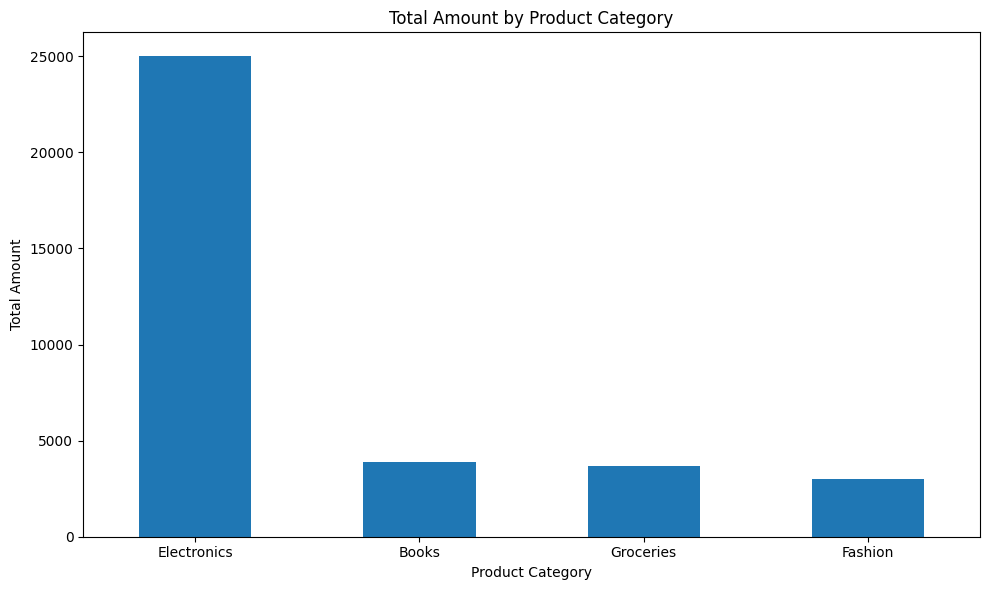

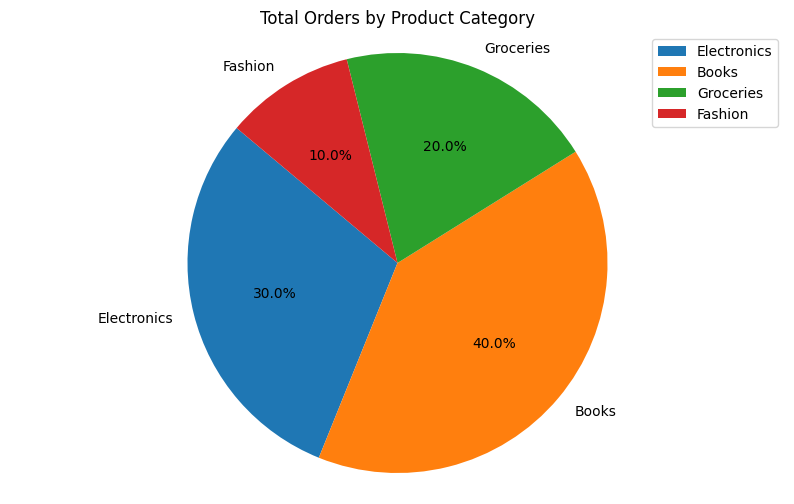

,customer_id,name,country,total_orders,total_amount
0,3,Sophia,USA,2,12000.0
1,1,Aisha,India,2,9700.0
2,5,Mei,Singapore,2,8600.0


,order_id,name,country,order_date,product_category,order_amount,payment_method
0,2,Aisha,India,2024-03-10,Electronics,8500.0,UPI
1,3,Rahul,India,2024-03-05,Groceries,1500.0,COD
2,1,Aisha,India,2024-03-01,Books,1200.0,CARD
3,4,Rahul,India,2024-03-18,Books,700.0,CARD


Number of records for Order in India: 4


,order_id,name,country,order_date,product_category,order_amount,payment_method
0,5,Sophia,USA,2024-03-12,Electronics,9000.0,CARD
1,6,Sophia,USA,2024-03-25,Fashion,3000.0,CARD


Number of records for Order in USA: 2


,order_id,name,country,order_date,product_category,order_amount,payment_method
0,8,Liam,UK,2024-03-21,Groceries,2200.0,CARD
1,7,Liam,UK,2024-03-07,Books,900.0,UPI


Number of records for Order in UK: 2


,order_id,name,country,order_date,product_category,order_amount,payment_method
0,9,Mei,Singapore,2024-03-15,Electronics,7500.0,UPI
1,10,Mei,Singapore,2024-03-28,Books,1100.0,CARD


Number of records for Order in Singapore: 2


In [39]:

# The main function is the entry point of the script, which calls the process_using_MySql_Connector function to transfer data from Python to MySQL database using MySQL Connector. This function is responsible for connecting to the MySQL database, executing SQL commands to create a table, insert records, and select records from the 'customers' table in the MySQL database. It also handles any exceptions that may occur during the connection and execution of SQL commands, and ensures that the MySQL connection is closed properly after all operations are completed.
def main():

     # connectdbtype = None
 
     # connectdbtype = "MySQL" # define the database type as "MySQL" to specify that the connection settings for MySQL should be retrieved from the settings.json file and that the data transfer should be performed using MySQL Connector.

     connectdbtype = "SQLite" # define the database type as "SQLite" to specify that the connection settings for SQLite should be retrieved from the settings.json file and that the data transfer should be performed using SQLite.


     print(f"Database type selected for connection: {connectdbtype}") # print the selected database type to verify that the correct database type has been selected for the connection.

     if connectdbtype == "MySQL":
       process_using_MySql_Connector() # call the function to transfer data from Python to MySQL database using MySQL Connector, which is an alternative method for connecting to MySQL databases and transferring data, providing flexibility in how the data transfer is performed. 

     if connectdbtype == "SQLite":
       process_using_SQLite() # call the function to transfer data from Python to SQLite database using SQLite, which is an alternative method for connecting to SQLite databases and transferring data, providing flexibility in how the data transfer is performed.


if __name__ == "__main__":
    main()
